# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Maria Putu Evelyne Corena Puryatma | 5054251011 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("bankruptcy.csv")
data

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [3]:
data.tail()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009
6818,0,0.493053,0.570105,0.549548,0.627409,0.627409,0.998080,0.801987,0.813800,0.313415,...,0.815956,0.000707,0.626680,0.627408,0.841019,0.275114,0.026793,0.565167,1,0.233902


In [4]:
print('Jumlah baris dan kolom:', data.shape)
print()
data.info()
print('\nJumlah missing value per kolom:')
print(data.isnull().sum().to_string())
data.describe().T

Jumlah baris dan kolom: (6819, 96)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-nu

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


Distribusi label Outcome:
Bankrupt?
0    6599
1     220

Kelas mayoritas: 0 (96.8% dari seluruh data)


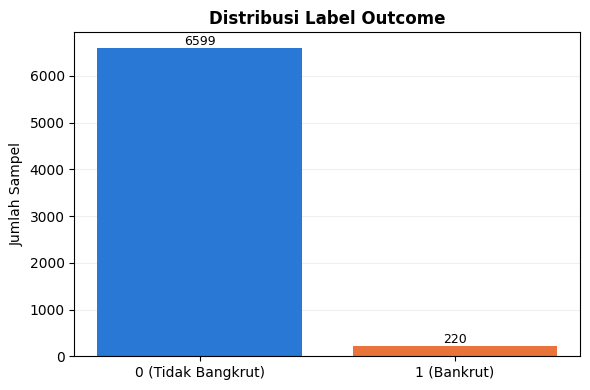

In [5]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
bankrupt_counts = data['Bankrupt?'].value_counts().sort_index()

print('Distribusi label Outcome:')
print(bankrupt_counts.to_string())
print(f'\nKelas mayoritas: {bankrupt_counts.idxmax()} '
      f'({bankrupt_counts.max() / len(data) * 100:.1f}% dari seluruh data)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['0 (Tidak Bangkrut)', '1 (Bankrut)'], bankrupt_counts.values, color=['#2a78d6', '#e8743b'])
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Label Outcome', fontsize=12, fontweight='bold')
for i, v in enumerate(bankrupt_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

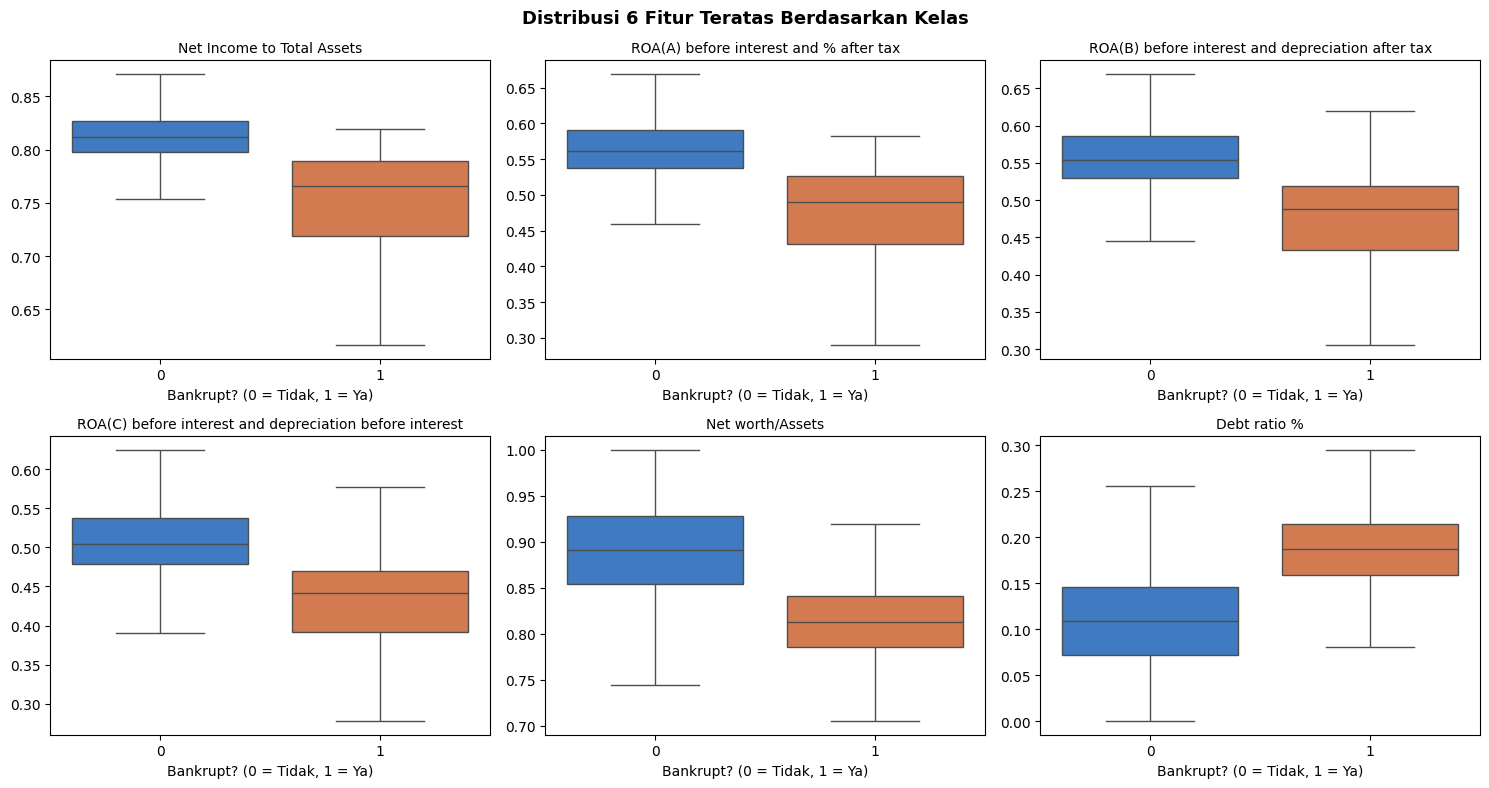

In [6]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

# Pilih 6 fitur yang korelasinya paling kuat dengan target, lalu buat boxplot per kelas.
# showfliers=False supaya outlier ekstrem tidak membuat grafik susah dibaca.
korelasi = data.corr()['Bankrupt?'].drop('Bankrupt?').abs().sort_values(ascending=False)
top_fitur = korelasi.head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, fitur in zip(axes.flatten(), top_fitur):
    sns.boxplot(data=data, x='Bankrupt?', y=fitur, ax=ax, showfliers=False,
                hue='Bankrupt?', palette=['#2a78d6', '#e8743b'], legend=False)
    ax.set_title(fitur.strip(), fontsize=10)
    ax.set_xlabel('Bankrupt? (0 = Tidak, 1 = Ya)')
    ax.set_ylabel('')
plt.suptitle('Distribusi 6 Fitur Teratas Berdasarkan Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Jumlah baris duplikat: 0
Fitur dengan nilai konstan: [' Net Income Flag']


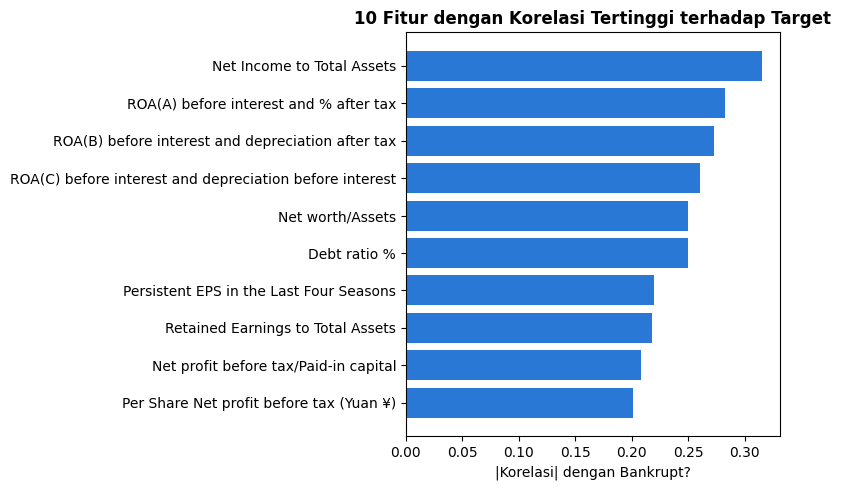

In [7]:
# EDA tambahan:
# 1) Cek data duplikat
print('Jumlah baris duplikat:', data.duplicated().sum())

# 2) Cek fitur yang nilainya hanya satu (konstan). Fitur seperti ini tidak berguna untuk split.
jumlah_unik = data.nunique()
print('Fitur dengan nilai konstan:', list(jumlah_unik[jumlah_unik == 1].index))

# 3) Bar chart 10 fitur dengan korelasi (absolut) tertinggi terhadap target
top10 = korelasi.head(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh([f.strip() for f in top10.index], top10.values, color='#2a78d6')
plt.xlabel('|Korelasi| dengan Bankrupt?')
plt.title('10 Fitur dengan Korelasi Tertinggi terhadap Target', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [8]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print('Total missing value:', data.isnull().sum().sum())
# Hasil: tidak ada missing value, jadi tidak perlu imputasi.
# (Jika ada, imputasi sebaiknya dihitung dari train set saja setelah split, agar tidak terjadi data leakage.)

# Hapus fitur konstan (hanya punya 1 nilai) karena tidak memberi informasi apa pun ke model.
data = data.drop(columns=[' Net Income Flag'])
print('Ukuran data setelah hapus fitur konstan:', data.shape)

Total missing value: 0
Ukuran data setelah hapus fitur konstan: (6819, 95)


In [9]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

print('Tipe data yang ada:')
print(data.dtypes.value_counts())
# Semua fitur sudah numerik (float64/int64), jadi tidak perlu encoding.

Tipe data yang ada:
float64    93
int64       2
Name: count, dtype: int64


In [10]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

from sklearn.model_selection import train_test_split

X = data.drop(columns=['Bankrupt?'])
y = data['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi kelas 1 di train: %.3f | di test: %.3f' % (y_train.mean(), y_test.mean()))

Train: (5455, 94) | Test: (1364, 94)
Proporsi kelas 1 di train: 0.032 | di test: 0.032


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

from sklearn.tree import DecisionTreeClassifier

model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)
print('Kedalaman pohon Gini:', model_gini.get_depth(), '| Jumlah daun:', model_gini.get_n_leaves())

Kedalaman pohon Gini: 19 | Jumlah daun: 125


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_gini = model_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [13]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)
print('Kedalaman pohon Entropy:', model_entropy.get_depth(), '| Jumlah daun:', model_entropy.get_n_leaves())

Kedalaman pohon Entropy: 18 | Jumlah daun: 101


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_entropy = model_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [15]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

from sklearn.metrics import f1_score

# Pilih kriteria terbaik berdasarkan F1-Score kelas 1 (Bangkrut),
# karena data imbalanced sehingga accuracy saja kurang tepat.
f1_gini = f1_score(y_test, y_pred_gini)
f1_entropy = f1_score(y_test, y_pred_entropy)
best_criterion = 'gini' if f1_gini >= f1_entropy else 'entropy'
print(f'F1 Gini: {f1_gini:.4f} | F1 Entropy: {f1_entropy:.4f} -> kriteria dipakai: {best_criterion}')

depth_list = [1, 2, 3, 5, 10, None]
depth_models = {}
for d in depth_list:
    m = DecisionTreeClassifier(criterion=best_criterion, max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    depth_models[d] = m

F1 Gini: 0.3409 | F1 Entropy: 0.3488 -> kriteria dipakai: entropy


In [16]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

from sklearn.metrics import accuracy_score

train_acc, test_acc, test_f1 = [], [], []
for d, m in depth_models.items():
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))
    test_f1.append(f1_score(y_test, m.predict(X_test)))

hasil_depth = pd.DataFrame({
    'max_depth': [str(d) for d in depth_list],
    'Train Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Selisih (Train - Test)': np.array(train_acc) - np.array(test_acc),
    'Test F1 (kelas 1)': test_f1,
})
hasil_depth.round(4)

,max_depth,Train Accuracy,Test Accuracy,Selisih (Train - Test),Test F1 (kelas 1)
0,1,0.9677,0.9677,-0.0000,0.0000
1,2,0.9677,0.9677,-0.0000,0.0000
2,3,0.9683,0.9699,-0.0017,0.2264
3,5,0.9743,0.9663,0.0081,0.4390
4,10,0.9930,0.9604,0.0326,0.3571
5,None,1.0000,0.9589,0.0411,0.3488


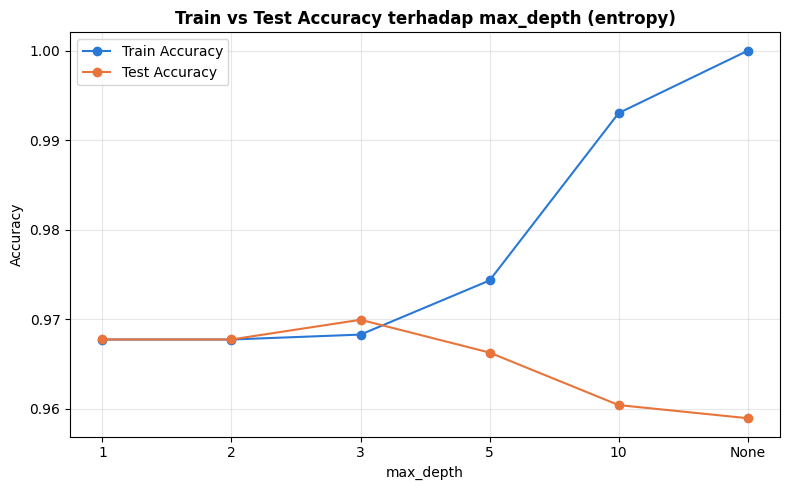

In [17]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

x_label = [str(d) for d in depth_list]  # None diubah jadi teks agar bisa diplot

plt.figure(figsize=(8, 5))
plt.plot(x_label, train_acc, marker='o', label='Train Accuracy', color='#2a78d6')
plt.plot(x_label, test_acc, marker='o', label='Test Accuracy', color='#e8743b')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title(f'Train vs Test Accuracy terhadap max_depth ({best_criterion})', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

from sklearn.metrics import precision_score, recall_score

# Precision, Recall, dan F1 dihitung untuk kelas 1 (Bangkrut), yaitu kelas yang ingin dideteksi.
def hitung_metrik(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

tabel_metrik = pd.DataFrame({
    'Gini': hitung_metrik(y_test, y_pred_gini),
    'Entropy': hitung_metrik(y_test, y_pred_entropy),
}).T
tabel_metrik.round(4)

,Accuracy,Precision,Recall,F1-Score
Gini,0.9575,0.3409,0.3409,0.3409
Entropy,0.9589,0.3571,0.3409,0.3488


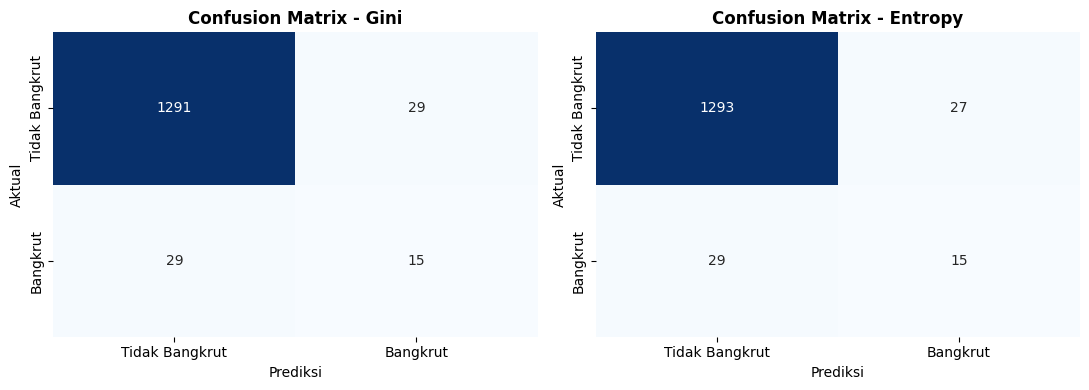

In [19]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nama, pred) in zip(axes, [('Gini', y_pred_gini), ('Entropy', y_pred_entropy)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Tidak Bangkrut', 'Bangkrut'],
                yticklabels=['Tidak Bangkrut', 'Bangkrut'])
    ax.set_title(f'Confusion Matrix - {nama}', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

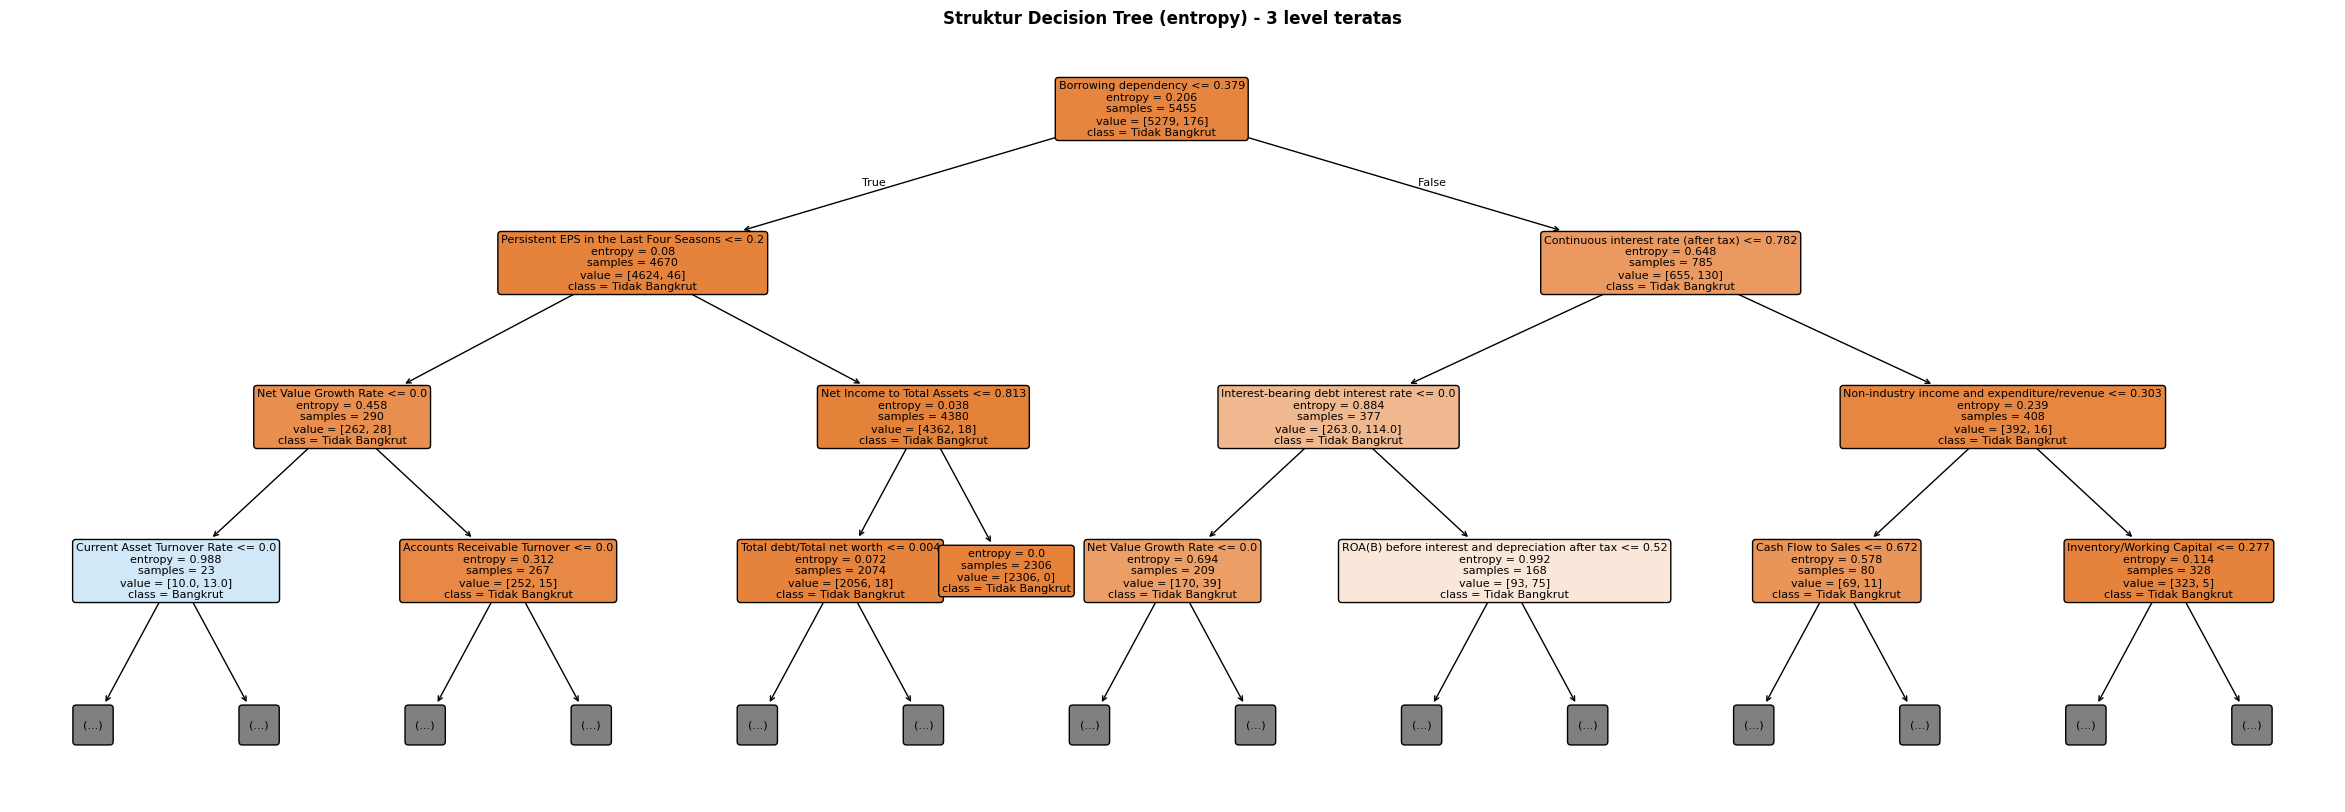

In [20]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

from sklearn.tree import plot_tree

best_model = model_gini if best_criterion == 'gini' else model_entropy

plt.figure(figsize=(30, 10))
plot_tree(best_model, max_depth=3, feature_names=[f.strip() for f in X.columns],
          class_names=['Tidak Bangkrut', 'Bangkrut'], filled=True, rounded=True, fontsize=8)
plt.title(f'Struktur Decision Tree ({best_criterion}) - 3 level teratas', fontweight='bold')
plt.show()

Borrowing dependency                       0.2146
Continuous interest rate (after tax)       0.0828
Persistent EPS in the Last Four Seasons    0.0635
Net Value Growth Rate                      0.0590
Quick Ratio                                0.0408
Operating Expense Rate                     0.0306
Interest-bearing debt interest rate        0.0292
Total Asset Growth Rate                    0.0250
Accounts Receivable Turnover               0.0244
Operating Profit Growth Rate               0.0233


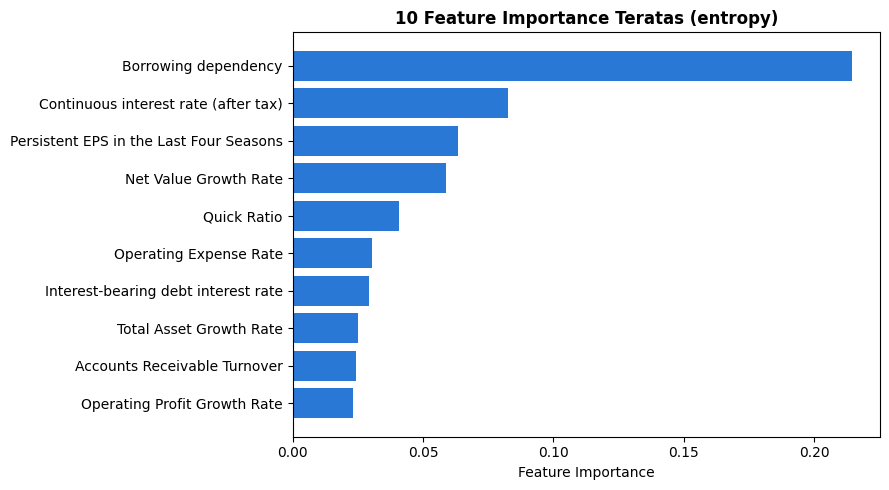

In [21]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

importance = pd.Series(best_model.feature_importances_, index=[f.strip() for f in X.columns])
top10_imp = importance.sort_values(ascending=False).head(10)
print(top10_imp.round(4).to_string())

plt.figure(figsize=(9, 5))
plt.barh(top10_imp.index[::-1], top10_imp.values[::-1], color='#2a78d6')  # dibalik agar terbesar di atas
plt.xlabel('Feature Importance')
plt.title(f'10 Feature Importance Teratas ({best_criterion})', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Jawaban Analisis

**1. Gini vs Entropy**

| Model | Accuracy | Precision | Recall | F1-Score | Kedalaman | Jumlah Daun |
|---|---|---|---|---|---|---|
| Gini | 0.9575 | 0.3409 | 0.3409 | 0.3409 | 19 | 125 |
| Entropy | 0.9589 | 0.3571 | 0.3409 | 0.3488 | 18 | 101 |

Hasil keduanya hampir sama dan tidak berbeda signifikan. Kedua model sama-sama menemukan 15 dari 44 perusahaan bangkrut di test set (recall 34%). Perbedaannya hanya pada false positive: Gini salah menebak 29 perusahaan sehat sebagai bangkrut, Entropy 27. Jadi selisihnya hanya 2 sampel. Gini dan Entropy sama-sama mengukur "seberapa campur" kelas di sebuah node. Keduanya bernilai 0 saat node murni dan maksimum saat kelas tercampur rata, dengan bentuk kurva yang mirip. Akibatnya, kedua kriteria cenderung memilih split yang hampir sama. Entropy menghasilkan pohon sedikit lebih kecil (101 daun vs 125), tetapi efeknya ke performa kecil.
Additional notes: data sangat imbalanced (96.8% tidak bangkrut). Model yang selalu menebak "tidak bangkrut" sudah mendapat accuracy 96.8%. Kedua model justru sedikit di bawah angka itu. Karena itu, metrik yang lebih jujur untuk kasus ini adalah Precision, Recall, dan F1 untuk kelas Bangkrut. Berdasarkan F1, Entropy sedikit lebih baik, sehingga Entropy dipakai untuk eksperimen max_depth.

**2. Eksperimen max_depth (kriteria Entropy)**

| max_depth | Train Acc | Test Acc | Selisih | Test F1 |
|---|---|---|---|---|
| 1 | 0.9677 | 0.9677 | 0.0000 | 0.0000 |
| 2 | 0.9677 | 0.9677 | 0.0000 | 0.0000 |
| 3 | 0.9683 | 0.9699 | -0.0017 | 0.2264 |
| 5 | 0.9743 | 0.9663 | 0.0081 | 0.4390 |
| 10 | 0.9930 | 0.9604 | 0.0326 | 0.3571 |
| None | 1.0000 | 0.9589 | 0.0411 | 0.3488 |

max_depth 1–2 = underfitting. Train dan test accuracy sama persis (0.9677), dan itu sama dengan proporsi kelas mayoritas. F1 = 0 artinya model tidak pernah menebak "Bangkrut". Pohon terlalu dangkal untuk mempelajari pola. max_depth 3 memberi test accuracy tertinggi (0.9699), dan train maupun test masih seimbang. Gejala overfitting mulai terlihat setelah max_depth 3, dan jelas sejak max_depth 5 ke atas. Pada grafik, garis train terus naik (0.968 → 0.974 → 0.993 → 1.000), sementara garis test justru turun (0.970 → 0.966 → 0.960 → 0.959). Jarak antara kedua garis makin lebar. Pada max_depth=None, train accuracy mencapai 100%, artinya pohon sudah "menghafal" data training, termasuk noise-nya. Jika dilihat dari F1 kelas Bangkrut, max_depth=5 adalah yang terbaik (F1 0.439). Nilai ini lebih baik daripada pohon tanpa batas (0.349). Jadi membatasi kedalaman tidak hanya mengurangi overfitting, tetapi juga membuat model lebih baik dalam mendeteksi perusahaan bangkrut.

**3. Feature Importance (model Entropy)**

Fitur paling berpengaruh adalah `Borrowing dependency` (0.215), jauh di atas fitur lain. Fitur ini juga menjadi split pertama (root) pada visualisasi pohon. Artinya, tingkat ketergantungan perusahaan pada pinjaman adalah pembeda paling kuat antara perusahaan bangkrut dan tidak. Setelah itu ada `Continuous interest rate (after tax)` (0.083), `Persistent EPS in the Last Four Seasons` (0.064), `Net Value Growth Rate` (0.059), dan `Quick Ratio` (0.041). Secara umum, fitur yang penting berkaitan dengan utang, profitabilitas, dan likuiditas. Ini masuk akal secara bisnis. Fitur dengan korelasi tertinggi saat EDA (Net Income to Total Assets dan ROA A/B/C) tidak semuanya muncul di urutan atas. Alasannya, fitur-fitur itu saling mirip (redundan). Begitu pohon memakai salah satunya, fitur lain yang mirip tidak menambah banyak informasi lagi. Feature importance ini berasal dari pohon tanpa batas kedalaman yang overfitting, jadi sebagian nilai kecil di bawahnya bisa berasal dari noise.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

Decision Tree dengan kriteria Gini dan Entropy memberikan hasil yang hampir sama pada dataset bankruptcy ini. Entropy sedikit lebih baik (F1 0.349 vs 0.341), tetapi selisihnya hanya 2 prediksi, sehingga tidak signifikan. Accuracy menyesatkan pada data imbalanced. Accuracy sekitar 96% terlihat tinggi, padahal model hanya berhasil menemukan sekitar 34% perusahaan yang bangkrut. Precision, Recall, dan F1 kelas Bangkrut lebih tepat untuk menilai model. max_depth sangat berpengaruh. Pohon terlalu dangkal (1–2) underfitting dan tidak pernah menebak Bangkrut. Pohon tanpa batas overfitting (train 100%, test turun). Kedalaman sekitar 3–5 adalah titik yang paling seimbang, dan max_depth=5 memberi F1 terbaik (0.439). Fitur yang paling menentukan kebangkrutan adalah `Borrowing dependency`, diikuti fitur terkait bunga, laba per saham, pertumbuhan nilai bersih, dan likuiditas.

### Saran

1. Tangani imbalance, misalnya dengan `class_weight='balanced'` pada DecisionTreeClassifier, agar model lebih memperhatikan kelas Bangkrut dan recall meningkat.
2. Pruning dengan `ccp_alpha`, atau mencoba `min_samples_leaf` dan `min_samples_split`, sebagai cara lain mencegah overfitting.
3. Cari hyperparameter dengan GridSearchCV + cross-validation(scoring F1) agar pemilihan max_depth tidak bergantung pada satu kali pembagian train/test saja. Test set hanya berisi 44 sampel bangkrut, jadi hasilnya bisa berubah cukup banyak jika split berbeda.
4. Bandingkan dengan model lain seperti Random Forest atau Gradient Boosting, yang biasanya lebih stabil daripada satu Decision Tree.